# Bays (2024) Figure 5 — Diagnosing the SD$_\mathrm{normal}$ Plateau

**Goal.** Reproduce the three-panel diagnostic figure from Ma, Husain & Bays (2014, *Nat Neurosci*) — Figure 5 in the paper — using *two* model pipelines:

1. **Our GP-based population coding model** (the same machinery used in the Figure 2 notebook).
2. **The Bays (2014) parametric reference model** (standalone implementation, taken from the Figure 2 notebook).

This is a **direct equivalence check**. If the GP variant reproduces the same SD_actual / SD_normal pattern that the parametric Bays model produces, that confirms our framework inherits the diagnostic implications of Bays (2014) — namely, that a continuous-resource model with no slots can masquerade as a slot model when fit with a normal-uniform mixture.

## What Figure 5 is actually about

Figure 5 dismantles a popular but flawed inference: that an apparent plateau in **SD_normal** as a function of set size proves the slot model. The argument runs in three steps, one per panel:

- **Panel (a)** — Aggregate human errors across all subjects and set sizes. Compute the model-free *actual* circular SD ($\sigma \approx 21.3°$). Fit the Zhang & Luck (2008) normal+uniform mixture, $p(\epsilon) = w \cdot \text{VonMises}(\epsilon; 0, \kappa) + (1-w) / (2\pi)$. Read off SD_normal from the fitted $\kappa$ (≈ 13.8°). The mixture absorbs the heavy tails into the uniform "guessing" component, leaving only the sharp peak for the Von Mises — so SD_normal is *much* smaller than SD_actual.

- **Panel (b)** — Repeat the same fit *separately at each set size* and plot SD_actual vs SD_normal as a function of $l$. SD_actual rises steeply with set size (this is the honest, model-free pattern). SD_normal appears to **plateau** at higher set sizes. Slot theorists interpreted this as: precision of stored items is fixed; extra items just fail to be stored (absorbed into the "uniform / guessing" component, where $1-w$ grows).

- **Panel (c)** — The punchline. Generate errors from a **variable-precision (continuous resource) model** — which by construction has *no slots* and no item limit — then run the *same* mixture-fitting pipeline. Both curves come out matching the data, including the spurious SD_normal plateau. **Conclusion:** the plateau is an artifact of fitting a misspecified two-component mixture to data that's actually an infinite mixture of precisions. SD_normal measures a property of the fit, not of memory.

## What this notebook does

Rather than fit a variable-precision model (we don't need it — we have something better), we use **our own GP population coding model** as the continuous-resource generator in panel (c). The logic of the diagnostic is identical: if our continuous, neural model produces a spurious SD_normal plateau, then the same conclusion applies — SD_normal cannot distinguish slot from non-slot accounts.

The Bays (2014) parametric model serves as a **secondary check**. Bays (2014) Figure 2 — and Ma/Husain/Bays (2014) Figure 5(c) — are run from the same machinery, so if our GP and the standalone Bays implementation give comparable SD_actual / SD_normal curves at matched parameters, we have a clean equivalence demonstration: GP and parametric tuning produce qualitatively the same diagnostic behaviour.

## Layout

- **Panel (a)** — Aggregate-error distribution + mixture fit, side-by-side for the Bays model and the GP model. SD_actual and SD_normal annotated on each.
- **Panel (b)** — SD_actual vs SD_normal across set sizes for the **Bays** model. This is the "ground truth" check — if Bays gives a plateau, our diagnostic is working.
- **Panel (c)** — Same plot for the **GP** model. This is the test of whether GP-generated errors masquerade as slots under the standard mixture fit.

## Note on terminology

The paper is Ma, Husain & Bays (2014), but it's often referenced by users as "Bays 2024" by shorthand. The notebook name follows that convention; the analyses follow the actual 2014 paper.

### Imports & Setup

In [ ]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from scipy.special import i0, i1, logsumexp
from scipy.optimize import minimize

from population import Population

print(f'Project root: {PROJECT_ROOT}')

In [2]:
def circular_sd(errors):
    """Fisher (1995) circular SD: sigma = sqrt(-2 log |m1|)."""
    R = np.abs(np.mean(np.exp(1j * np.asarray(errors))))
    return np.sqrt(-2.0 * np.log(max(R, 1e-15)))


def kappa_to_circular_sd(kappa):
    """Von Mises concentration kappa -> Fisher circular SD."""
    if kappa < 1e-6:
        return np.sqrt(-2.0 * np.log(1e-15))  # ~ infinity, but bounded
    if kappa > 700:
        kappa = 700.0
    R = float(i1(kappa) / i0(kappa))
    return np.sqrt(-2.0 * np.log(max(R, 1e-15)))


def _neg_log_lik_mixture(unconstrained_params, errors):
    """Negative log likelihood of normal-uniform mixture, with logit/log transforms."""
    logit_w, log_kappa = unconstrained_params
    w = 1.0 / (1.0 + np.exp(-logit_w))
    kappa = np.exp(log_kappa)

    # Von Mises density
    vm = np.exp(kappa * np.cos(errors)) / (2.0 * np.pi * i0(kappa))
    uniform = 1.0 / (2.0 * np.pi)
    mix = w * vm + (1.0 - w) * uniform

    return -np.sum(np.log(np.maximum(mix, 1e-300)))


def fit_normal_uniform_mixture(errors, init_w=0.85, init_kappa=10.0):
    """Maximum-likelihood fit of Zhang & Luck (2008) normal-uniform mixture.

    Returns
    -------
    w : float in (0, 1)        weight on Von Mises (the "stored" component)
    kappa : float > 0          concentration of Von Mises
    sd_normal : float          circular SD corresponding to kappa
    """
    errors = np.asarray(errors)
    logit_w0 = np.log(init_w / (1.0 - init_w))
    log_kappa0 = np.log(init_kappa)
    x0 = np.array([logit_w0, log_kappa0])

    result = minimize(_neg_log_lik_mixture, x0, args=(errors,),
                      method='Nelder-Mead',
                      options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 5000})

    logit_w, log_kappa = result.x
    w = 1.0 / (1.0 + np.exp(-logit_w))
    kappa = np.exp(log_kappa)
    sd_normal = kappa_to_circular_sd(kappa)
    return w, kappa, sd_normal


# Quick sanity check
rng_test = np.random.RandomState(0)
test_errors = rng_test.vonmises(0, 5.0, size=5000)  # pure von Mises, no uniform
w_hat, k_hat, sd_n_hat = fit_normal_uniform_mixture(test_errors)
print(f"Sanity check (pure VM with kappa=5):")
print(f"  fitted w={w_hat:.3f} (should be near 1), kappa={k_hat:.2f} (should be ~5)")
print(f"  SD_actual={np.rad2deg(circular_sd(test_errors)):.2f} deg, "
      f"SD_normal={np.rad2deg(sd_n_hat):.2f} deg  (should be ~equal)")

Sanity check (pure VM with kappa=5):
  fitted w=1.000 (should be near 1), kappa=5.07 (should be ~5)
  SD_actual=26.99 deg, SD_normal=26.99 deg  (should be ~equal)


### Bays (2014) - Original Parameter Generation

Standalone implementation of Bays's parametric population coding model, lifted verbatim from the Figure 2 notebook. Pure NumPy, no `core.*` dependencies. The point is to have an unambiguous Bays reference whose output we can compare against the GP variant on identical statistics.

| Bays equation | What it does |
|---|---|
| Eq. 1 | Tuning: $f_i(\theta) = \exp(\omega^{-1}(\cos(\phi_i - \theta) - 1))$ |
| Eq. 2/3 | DN: $r_{ij} = \gamma \cdot f_{ij} / \sum_{m,n} f_{mn}$ |
| Eq. 4 | Independent Poisson spike counts over $T_d$ |
| Eqs. 5–8 | ML decoder: $\hat\theta = \arg\max_\theta \sum_i n_i \cos(\phi_i - \theta)$ |

Three audit fixes vs. a naive port: (1) no semi-saturation $\sigma^2$ in the DN denominator (Bays Eq. 2 has none); (2) continuous orientation sampling (no encoding-grid quantisation); (3) random tie-breaking in `argmax` per Bays's explicit spec.

In [ ]:
def bays_run_trials(n_trials, set_size, omega, gamma_total, T_d,
                    M=100, rng=None, n_decode_grid=1000):
    """Vectorised batch implementation of Bays (2014) Experiment 1 pipeline.

    Standalone parametric Bays — uses Eq. 1 tuning at multiple locations with
    a shared divisive normalisation denominator that sums over (l, M). The
    `Population` class\'s `tuning_type=\'bays\'` mode is single-location by
    design (`L=1`), so we keep this multi-item reference here. For the GP
    pipeline below we route through `Population` directly.

    Returns signed circular errors of shape (n_trials,) in radians on [-pi, pi).
    """
    if rng is None:
        rng = np.random.RandomState()

    l = set_size
    phi = np.linspace(-np.pi, np.pi, M, endpoint=False)              # (M,)

    # 1-2. Sample stimuli
    theta_true = rng.uniform(-np.pi, np.pi, size=(n_trials, l))      # (T, l)
    cued = rng.randint(l, size=n_trials)                             # (T,)

    # 3. Eq. 1 driving inputs
    diff = phi[None, None, :] - theta_true[:, :, None]               # (T, l, M)
    f = np.exp((1.0 / omega) * (np.cos(diff) - 1.0))                 # (T, l, M)

    # 4. DN -- denom is per-trial sum over (l, M)
    denom = f.sum(axis=(1, 2))                                       # (T,)
    rates = gamma_total * f / denom[:, None, None]                   # (T, l, M)

    # 5. Poisson spikes
    counts = rng.poisson(rates * T_d)                                # (T, l, M)

    # 6. Pull out probed subpopulation
    counts_probed = counts[np.arange(n_trials), cued, :]             # (T, M)

    # ML decode (vectorised over trials)
    theta_eval = np.linspace(-np.pi, np.pi, n_decode_grid, endpoint=False)
    cos_grid = np.cos(phi[:, None] - theta_eval[None, :])            # (M, n_grid)
    objective = counts_probed @ cos_grid                             # (T, n_grid)

    # Random tie-breaking
    max_vals = objective.max(axis=1, keepdims=True)
    tied_mask = objective >= max_vals - 1e-12
    keys = rng.random(objective.shape) * tied_mask
    chosen_idx = keys.argmax(axis=1)
    theta_hat = theta_eval[chosen_idx]

    # 7. Signed circular error
    d = theta_hat - theta_true[np.arange(n_trials), cued]
    return (d + np.pi) % (2.0 * np.pi) - np.pi


print("Defined: bays_run_trials")

### GP Framework

The GP pipeline now routes through the unified `Population` class
(`tuning_type='gp'`). `Population.run_trials` performs the same vectorised
batch encode + decode as the prior bespoke `gp_run_trials`: it samples
`set_size` orientations on a deterministic location tuple, applies
population-level divisive normalisation, generates Poisson spikes, and
returns signed circular errors via the ML decoder. Setting
`active_locations=tuple(range(set_size))` and `probe_cued=True` exactly
matches the original convention of always probing location 0.

In [ ]:
def build_gp_population(M, n_theta, omega, n_locations, seed,
                        lengthscale_variability=0.3, gain_variability=0.0):
    """Construct the heterogeneous GP `Population` used downstream.

    Returns a `Population` instance whose `run_trials` method is the
    GP-pipeline analog of `bays_run_trials`. Bays\'s tuning width `omega`
    maps to the GP lengthscale internally via `lambda = sqrt(omega)`
    (handled inside `Population._build_gp`).
    """
    return Population(
        M=M,
        n_theta=n_theta,
        omega=omega,
        tuning_type='gp',
        n_locations=n_locations,
        seed=seed,
        lengthscale_variability=lengthscale_variability,
        gain_variability=gain_variability,
    )


print("Defined: build_gp_population")

#### Configuration — all tunable knobs in one cell

Everything you might want to play with lives in the single cell below: the number of neurons, trials per set size, the range of set sizes, the Bays tuning width $\omega$, the GP heterogeneity controls, the decoding window, and so on. Re-run from this cell to apply changes — the model definitions above don't need to be touched.

The defaults match Bays (2014) Experiment 1 group-mean ML parameters: $\omega = 0.52$, $\gamma_\text{total} = 119$ Hz, $M = 100$, $T_d = 0.1$ s. The $\omega \leftrightarrow \lambda$ mapping ($\lambda = \sqrt{\omega}$) and the gain conversion ($\gamma_\text{per neuron} = \gamma_\text{total} / M$) make the GP variant numerically comparable to the Bays parametric model.

In [5]:
# ============================================================
# === PARAMETERS — edit here to play with the experiment ===
# ============================================================

# --- Shared (both Bays parametric and GP variant) ---
M = 100                           # number of neurons
N_TRIALS = 5000                   # trials per set size (per model)
T_D = 0.1                         # decoding window (s)
SET_SIZES = list(range(1, 9))     # set sizes to sweep over: 1, 2, ..., 8
SEED = 42

# --- Bays parametric model ---
OMEGA_BAYS = 0.52                 # tuning width (group-mean ML fit, Bays 2014 Fig 2b)
GAMMA_TOTAL_BAYS = 119.0          # total population gain (Hz)
N_DECODE_GRID = 1000              # orientation grid for Bays ML decoder

# --- GP variant ---
N_THETA_GP = 128                  # orientation grid resolution for GP tuning curves
LENGTHSCALE_VARIABILITY = 0.3     # spread of GP lengthscales across locations
GAIN_VARIABILITY = 0.0            # spread of amplitude scaling (0 = homogeneous)
SIGMA_SQ = 1e-6                   # DN semi-saturation constant

# --- Derived (don't edit directly) ---
LAMBDA_BASE = np.sqrt(OMEGA_BAYS)              # omega = lambda^2 mapping
GAMMA_PER_NEURON = GAMMA_TOTAL_BAYS / M         # match per-neuron rate to Bays total

print('=== Configuration ===')
print(f'M = {M} neurons,  T_D = {T_D}s,  N_TRIALS = {N_TRIALS} per set size')
print(f'Set sizes: {SET_SIZES}')
print()
print('Bays parametric:')
print(f'  omega = {OMEGA_BAYS}')
print(f'  gamma_total = {GAMMA_TOTAL_BAYS} Hz')
print(f'  decode grid = {N_DECODE_GRID}')
print()
print('GP variant:')
print(f'  lambda = sqrt(omega) = {LAMBDA_BASE:.4f}')
print(f'  gamma_per_neuron = gamma_total / M = {GAMMA_PER_NEURON:.3f} Hz')
print(f'  n_theta = {N_THETA_GP}')
print(f'  lengthscale_variability = {LENGTHSCALE_VARIABILITY}')
print(f'  gain_variability = {GAIN_VARIABILITY}')

=== Configuration ===
M = 100 neurons,  T_D = 0.1s,  N_TRIALS = 5000 per set size
Set sizes: [1, 2, 3, 4, 5, 6, 7, 8]

Bays parametric:
  omega = 0.52
  gamma_total = 119.0 Hz
  decode grid = 1000

GP variant:
  lambda = sqrt(omega) = 0.7211
  gamma_per_neuron = gamma_total / M = 1.190 Hz
  n_theta = 128
  lengthscale_variability = 0.3
  gain_variability = 0.0


## Sweep the Bays model across set sizes

For each $l$, generate `N_TRIALS` errors, then compute SD_actual and SD_normal via the mixture fit. Store the raw errors as well — we'll need them for Panel (a).

In [6]:
t0 = time.time()
bays_results = {}
rng_bays = np.random.RandomState(SEED)
for N in SET_SIZES:
    errors = bays_run_trials(
        n_trials=N_TRIALS, set_size=N,
        omega=OMEGA_BAYS, gamma_total=GAMMA_TOTAL_BAYS, T_d=T_D,
        M=M, rng=rng_bays, n_decode_grid=1000)

    sd_actual = circular_sd(errors)
    w_hat, kappa_hat, sd_normal = fit_normal_uniform_mixture(errors)

    bays_results[N] = {
        'errors': errors,
        'sd_actual': sd_actual,
        'sd_normal': sd_normal,
        'w': w_hat,
        'kappa': kappa_hat,
    }
    print(f'  Bays l={N}:  SD_actual={np.rad2deg(sd_actual):6.2f} deg   '
          f'SD_normal={np.rad2deg(sd_normal):6.2f} deg   '
          f'w={w_hat:.3f}   kappa={kappa_hat:.2f}')
print(f'Bays sweep done in {time.time()-t0:.1f}s')

  Bays l=1:  SD_actual= 15.38 deg   SD_normal= 15.22 deg   w=0.999   kappa=14.69
  Bays l=2:  SD_actual= 24.34 deg   SD_normal= 22.16 deg   w=0.982   kappa=7.22
  Bays l=3:  SD_actual= 32.24 deg   SD_normal= 27.58 deg   w=0.956   kappa=4.88
  Bays l=4:  SD_actual= 39.53 deg   SD_normal= 30.50 deg   w=0.905   kappa=4.12
  Bays l=5:  SD_actual= 46.00 deg   SD_normal= 33.53 deg   w=0.858   kappa=3.53
  Bays l=6:  SD_actual= 50.04 deg   SD_normal= 34.83 deg   w=0.817   kappa=3.32
  Bays l=7:  SD_actual= 52.80 deg   SD_normal= 35.89 deg   w=0.792   kappa=3.17
  Bays l=8:  SD_actual= 59.06 deg   SD_normal= 37.13 deg   w=0.720   kappa=3.01
Bays sweep done in 1.0s


## Sweep the GP model across set sizes

We build a single GP population once with `max(SET_SIZES) = 8` locations and reuse it across set sizes — orientations at unused locations are simply ignored. This mirrors the Figure 2 notebook's approach.

In [ ]:
t0 = time.time()
pop_gp = build_gp_population(
    M=M, n_theta=N_THETA_GP, omega=OMEGA_BAYS,
    n_locations=max(SET_SIZES), seed=SEED,
    lengthscale_variability=LENGTHSCALE_VARIABILITY,
    gain_variability=GAIN_VARIABILITY)
print(f'GP population built in {time.time()-t0:.1f}s   '
      f'(f shape: M={pop_gp.N}, L={pop_gp.L}, n_theta={pop_gp.n_theta})')

t0 = time.time()
gp_results = {}
for N in SET_SIZES:
    rng = np.random.RandomState(SEED + N)
    errors = pop_gp.run_trials(
        n_trials=N_TRIALS,
        gamma=GAMMA_PER_NEURON,
        T_d=T_D,
        set_size=N,
        sigma_sq=SIGMA_SQ,
        rng=rng,
        active_locations=tuple(range(N)),   # match prior gp_run_trials convention
        probe_cued=True,                    # always probe location 0
    )

    sd_actual = circular_sd(errors)
    w_hat, kappa_hat, sd_normal = fit_normal_uniform_mixture(errors)

    gp_results[N] = {
        'errors': errors,
        'sd_actual': sd_actual,
        'sd_normal': sd_normal,
        'w': w_hat,
        'kappa': kappa_hat,
    }
    print(f'  GP   l={N}:  SD_actual={np.rad2deg(sd_actual):6.2f} deg   '
          f'SD_normal={np.rad2deg(sd_normal):6.2f} deg   '
          f'w={w_hat:.3f}   kappa={kappa_hat:.2f}')
print(f'GP sweep done in {time.time()-t0:.1f}s')

### Plot The figure — two rows (Bays / GP), two panels each

Layout matches Bays 2024 Figure 5 stylistically: errors in **degrees** on a $[-180°, +180°]$ axis (the colour-wheel convention), **SD_actual in black, SD_normal in red**.

- **Row 1 (Bays parametric)**
  - **(a)** aggregate error distribution + fitted normal-uniform mixture
  - **(b)** SD_actual vs SD_normal across set sizes

- **Row 2 (GP variant)**
  - **(a)** aggregate error distribution + fitted normal-uniform mixture
  - **(b)** SD_actual vs SD_normal across set sizes

The two row-(b) panels share y-axis limits so the comparison between Bays and GP is direct. If our framework is doing what we think it does, the two row-(b) panels should look qualitatively similar — SD_actual climbing steeply with set size, SD_normal climbing more slowly and showing the characteristic apparent plateau.

In [8]:
# --- Panel (a) inputs: aggregate errors across all set sizes ---
bays_all_errors = np.concatenate([bays_results[N]['errors'] for N in SET_SIZES])
gp_all_errors   = np.concatenate([gp_results[N]['errors']   for N in SET_SIZES])

# Fit the mixture to the aggregate (single number per model)
bays_sd_actual_agg = circular_sd(bays_all_errors)
bays_w_agg, bays_kappa_agg, bays_sd_normal_agg = fit_normal_uniform_mixture(bays_all_errors)

gp_sd_actual_agg = circular_sd(gp_all_errors)
gp_w_agg, gp_kappa_agg, gp_sd_normal_agg = fit_normal_uniform_mixture(gp_all_errors)

print(f'Bays aggregate:  SD_actual={np.rad2deg(bays_sd_actual_agg):.2f} deg, '
      f'SD_normal={np.rad2deg(bays_sd_normal_agg):.2f} deg, '
      f'w={bays_w_agg:.3f}')
print(f'GP   aggregate:  SD_actual={np.rad2deg(gp_sd_actual_agg):.2f} deg, '
      f'SD_normal={np.rad2deg(gp_sd_normal_agg):.2f} deg, '
      f'w={gp_w_agg:.3f}')

Bays aggregate:  SD_actual=41.31 deg, SD_normal=27.61 deg, w=0.857
GP   aggregate:  SD_actual=52.32 deg, SD_normal=16.64 deg, w=0.670


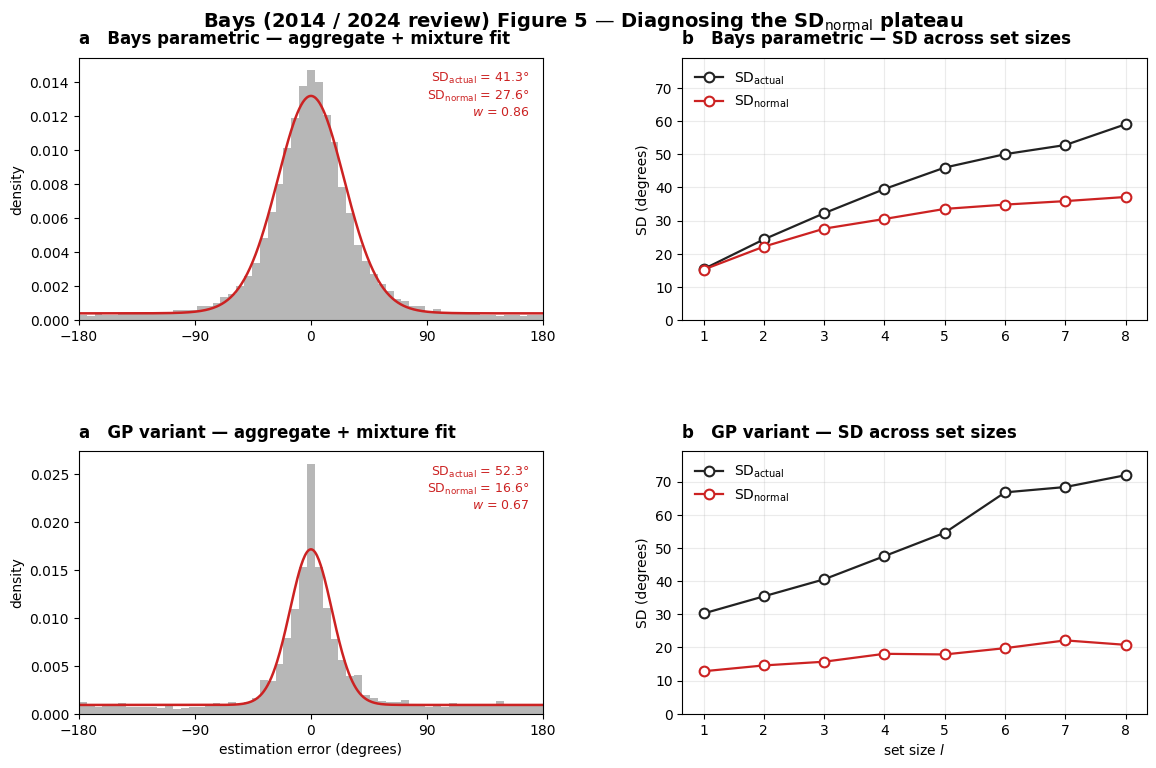

In [9]:
# Colours -- match Bays 2024 Figure 5: SD_actual in black, SD_normal in red.
BLACK = '#222222'
RED   = '#CC2222'
GRAY  = '#888888'


def mixture_pdf(eps_rad, w, kappa):
    """Normal+uniform mixture density on the circle (input in radians)."""
    vm = np.exp(kappa * np.cos(eps_rad)) / (2.0 * np.pi * i0(kappa))
    return w * vm + (1.0 - w) * (1.0 / (2.0 * np.pi))


# === Build the 2-row x 2-col grid ===
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2,
                       hspace=0.50, wspace=0.30,
                       left=0.08, right=0.97, bottom=0.09, top=0.91)

# Histogram bin edges in DEGREES (we'll convert errors degree-wise too)
edges_deg = np.linspace(-180, 180, 60)
eps_grid_deg = np.linspace(-180, 180, 500)
eps_grid_rad = np.deg2rad(eps_grid_deg)

# Set-size axis in degrees and a shared SD axis range for the two row-(b) panels
ns = np.array(SET_SIZES, dtype=float)
sd_actual_bays = np.array([np.rad2deg(bays_results[N]['sd_actual']) for N in SET_SIZES])
sd_normal_bays = np.array([np.rad2deg(bays_results[N]['sd_normal']) for N in SET_SIZES])
sd_actual_gp   = np.array([np.rad2deg(gp_results[N]['sd_actual'])   for N in SET_SIZES])
sd_normal_gp   = np.array([np.rad2deg(gp_results[N]['sd_normal'])   for N in SET_SIZES])
ymax_b = max(sd_actual_bays.max(), sd_actual_gp.max()) * 1.10


def plot_panel_a(ax, all_errors_rad, w, kappa, sd_actual_rad, sd_normal_rad,
                 title, show_xlabel=True):
    """Aggregate distribution + mixture overlay. Errors converted to degrees."""
    all_errors_deg = np.rad2deg(all_errors_rad)
    ax.hist(all_errors_deg, bins=edges_deg, density=True,
            color=GRAY, alpha=0.6, edgecolor='none')
    # mixture_pdf is per-radian; convert to per-degree by * (pi/180)
    pdf_per_deg = mixture_pdf(eps_grid_rad, w, kappa) * (np.pi / 180.0)
    ax.plot(eps_grid_deg, pdf_per_deg, color=RED, lw=1.8)
    ax.set_xlim(-180, 180)
    ax.set_xticks([-180, -90, 0, 90, 180])
    if show_xlabel:
        ax.set_xlabel('estimation error (degrees)', fontsize=10)
    ax.set_ylabel('density', fontsize=10)
    ax.set_title(title, loc='left', fontweight='bold', fontsize=12, pad=10)
    ax.text(0.97, 0.95,
            f'SD$_\\mathrm{{actual}}$ = {np.rad2deg(sd_actual_rad):.1f}\u00b0\n'
            f'SD$_\\mathrm{{normal}}$ = {np.rad2deg(sd_normal_rad):.1f}\u00b0\n'
            f'$w$ = {w:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color=RED,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.9))


def plot_panel_b(ax, sd_actual_arr, sd_normal_arr, title, show_xlabel=True):
    """SD_actual (black) vs SD_normal (red) across set sizes."""
    ax.plot(ns, sd_actual_arr, 'o-', color=BLACK, lw=1.6, ms=7,
            label=r'SD$_\mathrm{actual}$', mfc='white', mew=1.5)
    ax.plot(ns, sd_normal_arr, 'o-', color=RED, lw=1.6, ms=7,
            label=r'SD$_\mathrm{normal}$', mfc='white', mew=1.5)
    ax.set_xticks(SET_SIZES)
    if show_xlabel:
        ax.set_xlabel('set size $l$', fontsize=10)
    ax.set_ylabel('SD (degrees)', fontsize=10)
    ax.set_ylim(0, ymax_b)
    ax.set_title(title, loc='left', fontweight='bold', fontsize=12, pad=10)
    ax.legend(fontsize=10, loc='upper left', frameon=False)
    ax.grid(alpha=0.25)


# --- Row 1: Bays parametric ---
ax_1a = fig.add_subplot(gs[0, 0])
plot_panel_a(ax_1a, bays_all_errors, bays_w_agg, bays_kappa_agg,
             bays_sd_actual_agg, bays_sd_normal_agg,
             title='a   Bays parametric — aggregate + mixture fit',
             show_xlabel=False)

ax_1b = fig.add_subplot(gs[0, 1])
plot_panel_b(ax_1b, sd_actual_bays, sd_normal_bays,
             title='b   Bays parametric — SD across set sizes',
             show_xlabel=False)

# --- Row 2: GP variant ---
ax_2a = fig.add_subplot(gs[1, 0])
plot_panel_a(ax_2a, gp_all_errors, gp_w_agg, gp_kappa_agg,
             gp_sd_actual_agg, gp_sd_normal_agg,
             title='a   GP variant — aggregate + mixture fit',
             show_xlabel=True)

ax_2b = fig.add_subplot(gs[1, 1])
plot_panel_b(ax_2b, sd_actual_gp, sd_normal_gp,
             title='b   GP variant — SD across set sizes',
             show_xlabel=True)

fig.suptitle(
    'Bays (2014 / 2024 review) Figure 5 \u2014 Diagnosing the SD$_\\mathrm{normal}$ plateau',
    fontsize=14, fontweight='bold', y=0.97)

plt.savefig('bays_2024_figure_5.png', dpi=150, bbox_inches='tight')
plt.show()